# LP vs PPO: So sánh VM Allocation theo từng Scenario

So sánh hai phương pháp phân bổ VM trên **cùng kịch bản tối ưu hóa**:

| Scenario | LP | PPO |
|----------|-----|-----|
| **OVERLOAD** | Minimize Resource Overload | Minimize SLA Violations |
| **COST** | Minimize Operational Cost | Minimize Operational Cost |

## Tiêu chí so sánh (per-step)
1. **Tổng số máy ảo** sử dụng
2. **Tỷ lệ sử dụng tài nguyên** (CPU/Memory utilization)
3. **Chi phí thuê vận hành VM**


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

# Cấu hình hiển thị
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

RESULTS_DIR = Path('forecast_result')
print('✓ Libraries loaded')


✓ Libraries loaded


## 1. Load dữ liệu từ LP và PPO


In [38]:
# Load LP schedules (BOTH scenarios)
lp_overload_path = RESULTS_DIR / 'lp_schedule_overload.csv'
lp_cost_path = RESULTS_DIR / 'lp_schedule_cost.csv'

print("=== Loading LP Schedules ===")
if lp_overload_path.exists():
    lp_overload_df = pd.read_csv(lp_overload_path)
    lp_overload_df['timestamp'] = pd.to_datetime(lp_overload_df['timestamp'])
    print(f'LP (Overload):      {len(lp_overload_df):,} steps')
else:
    print(f'⚠️ LP Overload not found. Run: python vm_resource_planner.py --mode reactive')
    lp_overload_df = None

if lp_cost_path.exists():
    lp_cost_df = pd.read_csv(lp_cost_path)
    lp_cost_df['timestamp'] = pd.to_datetime(lp_cost_df['timestamp'])
    print(f'LP (Cost):          {len(lp_cost_df):,} steps')
else:
    print(f'⚠️ LP Cost not found. Run: python vm_resource_planner.py --mode reactive')
    lp_cost_df = None

# Load PPO schedules (both scenarios)
print("\n=== Loading PPO Schedules ===")
ppo_overload_df = pd.read_csv(RESULTS_DIR / 'ppo_schedule_test_overload.csv')
ppo_cost_df = pd.read_csv(RESULTS_DIR / 'ppo_schedule_test_cost.csv')
print(f'PPO (Overload):     {len(ppo_overload_df):,} steps')
print(f'PPO (Cost):         {len(ppo_cost_df):,} steps')

# Số steps để so sánh công bằng
n_steps = min(len(ppo_overload_df), len(ppo_cost_df))
print(f'\n→ So sánh trên {n_steps} steps đầu tiên')

# Cắt LP về cùng số steps với PPO
if lp_overload_df is not None:
    lp_overload_df = lp_overload_df.iloc[:n_steps].copy()
if lp_cost_df is not None:
    lp_cost_df = lp_cost_df.iloc[:n_steps].copy()


=== Loading LP Schedules ===
LP (Overload):      17,150 steps
LP (Cost):          17,150 steps

=== Loading PPO Schedules ===
PPO (Overload):     17,150 steps
PPO (Cost):         17,150 steps

→ So sánh trên 17150 steps đầu tiên


In [39]:
# Preview LP data (both scenarios)
print('=== LP Overload Schedule Preview ===')
if lp_overload_df is not None:
    display(lp_overload_df[['timestamp', 'allocation', 'vm_total_count', 'vm_cost_per_hour', 
           'cpu_utilization_pct', 'sla_violation']].head(5))

print('\n=== LP Cost Schedule Preview ===')
if lp_cost_df is not None:
    display(lp_cost_df[['timestamp', 'allocation', 'vm_total_count', 'vm_cost_per_hour', 
           'cpu_utilization_pct', 'sla_violation']].head(5))


=== LP Overload Schedule Preview ===


,timestamp,allocation,vm_total_count,vm_cost_per_hour,cpu_utilization_pct,sla_violation
0,2024-01-01 00:00:00,Host only,0,0.0,0.0,0
1,2024-01-01 00:00:30,Host only,0,0.0,0.0,0
2,2024-01-01 00:01:00,Host only,0,0.0,0.0,0
3,2024-01-01 00:01:30,Host only,0,0.0,0.0,0
4,2024-01-01 00:02:00,Host only,0,0.0,0.0,0



=== LP Cost Schedule Preview ===


,timestamp,allocation,vm_total_count,vm_cost_per_hour,cpu_utilization_pct,sla_violation
0,2024-01-01 00:00:00,Host only,0,0.0,0.0,0
1,2024-01-01 00:00:30,Host only,0,0.0,0.0,0
2,2024-01-01 00:01:00,Host only,0,0.0,0.0,0
3,2024-01-01 00:01:30,Host only,0,0.0,0.0,0
4,2024-01-01 00:02:00,Host only,0,0.0,0.0,0


In [40]:
# Preview PPO data (both scenarios)
print('=== PPO Overload Schedule Preview ===')
display(ppo_overload_df[['timestamp', 'allocation', 'vm_cost_per_hour', 
         'cpu_utilization_pct', 'sla_violation_flag']].head(5))

print('\n=== PPO Cost Schedule Preview ===')
display(ppo_cost_df[['timestamp', 'allocation', 'vm_cost_per_hour', 
         'cpu_utilization_pct', 'sla_violation_flag']].head(5))


=== PPO Overload Schedule Preview ===


,timestamp,allocation,vm_cost_per_hour,cpu_utilization_pct,sla_violation_flag
0,1970-01-25 01:05:30,Host only,0.0,0.0,0
1,1970-01-25 01:06:00,Host only,0.0,0.0,0
2,1970-01-25 01:06:30,Host only,0.0,0.0,0
3,1970-01-25 01:07:00,Host only,0.0,0.0,0
4,1970-01-25 01:07:30,Host only,0.0,0.0,0



=== PPO Cost Schedule Preview ===


,timestamp,allocation,vm_cost_per_hour,cpu_utilization_pct,sla_violation_flag
0,1970-01-25 01:05:30,Host only,0.0,0.0,0
1,1970-01-25 01:06:00,Host only,0.0,0.0,0
2,1970-01-25 01:06:30,Host only,0.0,0.0,0
3,1970-01-25 01:07:00,Host only,0.0,0.0,0
4,1970-01-25 01:07:30,Host only,0.0,0.0,0


## 2. Trích xuất & Tính toán Metrics


In [41]:
def extract_vm_count(allocation_str):
    """Trích xuất tổng số VM từ chuỗi allocation
    
    Supports both formats:
    - LP format: 'B2s×2, D2s_v3×1' (× separator)
    - PPO format: 'B2s:2, D2s_v3:1' (: separator)
    """
    if pd.isna(allocation_str) or allocation_str in ['Host only', 'No VMs']:
        return 0
    total = 0
    parts = str(allocation_str).split(',')
    for part in parts:
        part = part.strip()
        # Try both separators: × (LP) and : (PPO)
        if '×' in part:
            try:
                count = int(part.split('×')[1])
                total += count
            except (ValueError, IndexError):
                pass
        elif ':' in part:
            try:
                count = int(part.split(':')[1])
                total += count
            except (ValueError, IndexError):
                pass
    return total

# Tính vm_count cho PPO
ppo_cost_df['vm_count'] = ppo_cost_df['allocation'].apply(extract_vm_count)
ppo_overload_df['vm_count'] = ppo_overload_df['allocation'].apply(extract_vm_count)

# Tính vm_count cho LP (dùng vm_total_count nếu có, hoặc trích từ allocation)
if lp_overload_df is not None:
    if 'vm_total_count' in lp_overload_df.columns:
        lp_overload_df['vm_count'] = lp_overload_df['vm_total_count']
    else:
        lp_overload_df['vm_count'] = lp_overload_df['allocation'].apply(extract_vm_count)

if lp_cost_df is not None:
    if 'vm_total_count' in lp_cost_df.columns:
        lp_cost_df['vm_count'] = lp_cost_df['vm_total_count']
    else:
        lp_cost_df['vm_count'] = lp_cost_df['allocation'].apply(extract_vm_count)

print('✓ VM counts extracted for all methods')


✓ VM counts extracted for all methods


In [42]:
def compute_metrics(df, name, cost_col='vm_cost_per_hour', 
                    cpu_col='cpu_utilization_pct', mem_col='mem_utilization_pct',
                    sla_col='sla_violation'):
    """Tính metrics per-step cho một phương pháp"""
    
    # Handle different column names
    if sla_col not in df.columns and 'sla_violation_flag' in df.columns:
        sla_col = 'sla_violation_flag'
    
    n = len(df)
    
    # 1. Tổng số VM
    total_vms = int(df['vm_count'].sum())
    avg_vms = df['vm_count'].mean()
    max_vms = int(df['vm_count'].max())
    steps_with_vms = int((df['vm_count'] > 0).sum())
    
    # 2. Tỷ lệ sử dụng tài nguyên (chỉ khi có VM)
    vm_steps = df[df['vm_count'] > 0]
    cpu_util = vm_steps[cpu_col].mean() if len(vm_steps) > 0 else 0
    mem_util = vm_steps[mem_col].mean() if len(vm_steps) > 0 else 0
    
    # 3. Chi phí vận hành (per-step sum)
    total_cost = df[cost_col].sum()
    avg_cost = df[cost_col].mean()
    
    # SLA violations
    sla_violations = int(df[sla_col].sum())
    
    return {
        'Method': name,
        'Steps': n,
        'Total VMs': total_vms,
        'Avg VMs/Step': round(avg_vms, 3),
        'Max VMs': max_vms,
        'Steps with VMs': steps_with_vms,
        'CPU Util %': round(cpu_util, 2),
        'Mem Util %': round(mem_util, 2),
        'Total Cost ($/h)': round(total_cost, 4),
        'Avg Cost/Step': round(avg_cost, 4),
        'SLA Violations': sla_violations,
    }

# Tính metrics theo TỪNG SCENARIO
metrics_overload = []
metrics_cost = []

# Scenario: OVERLOAD (LP vs PPO)
if lp_overload_df is not None:
    metrics_overload.append(compute_metrics(lp_overload_df, 'LP'))
metrics_overload.append(compute_metrics(ppo_overload_df, 'PPO'))

# Scenario: COST (LP vs PPO)
if lp_cost_df is not None:
    metrics_cost.append(compute_metrics(lp_cost_df, 'LP'))
metrics_cost.append(compute_metrics(ppo_cost_df, 'PPO'))

print(f'✓ Metrics computed for {n_steps} steps per scenario')


✓ Metrics computed for 17150 steps per scenario


## 3. Bảng So sánh theo Scenario


In [43]:
# Bảng so sánh cho SCENARIO: OVERLOAD
print("="*60)
print("    SCENARIO: OVERLOAD (Minimize Resource Overload)")
print("="*60)
if metrics_overload:
    df_overload = pd.DataFrame(metrics_overload).set_index('Method')
    display(df_overload.T)


    SCENARIO: OVERLOAD (Minimize Resource Overload)


Method,LP,PPO
Steps,17150.0000,17150.0000
Total VMs,2738.0000,1752.0000
Avg VMs/Step,0.1600,0.1020
Max VMs,1.0000,19.0000
Steps with VMs,2738.0000,389.0000
CPU Util %,5.6000,5.1000
Mem Util %,0.0000,0.0000
Total Cost ($/h),4205.5680,185.3248
Avg Cost/Step,0.2452,0.0108
SLA Violations,0.0000,5.0000


In [44]:
# Bảng so sánh cho SCENARIO: COST
print("="*60)
print("    SCENARIO: COST (Minimize Operational Cost)")
print("="*60)
if metrics_cost:
    df_cost = pd.DataFrame(metrics_cost).set_index('Method')
    display(df_cost.T)


    SCENARIO: COST (Minimize Operational Cost)


Method,LP,PPO
Steps,17150.0000,17150.0000
Total VMs,4015.0000,1193.0000
Avg VMs/Step,0.2340,0.0700
Max VMs,7.0000,16.0000
Steps with VMs,2738.0000,220.0000
CPU Util %,53.6200,8.0200
Mem Util %,0.0000,0.0000
Total Cost ($/h),167.0240,101.2704
Avg Cost/Step,0.0097,0.0059
SLA Violations,0.0000,174.0000


## 4. Visualizations


In [45]:
# Color palette
COLORS = {
    'LP': '#2ecc71',    # Green
    'PPO': '#3498db',   # Blue
}


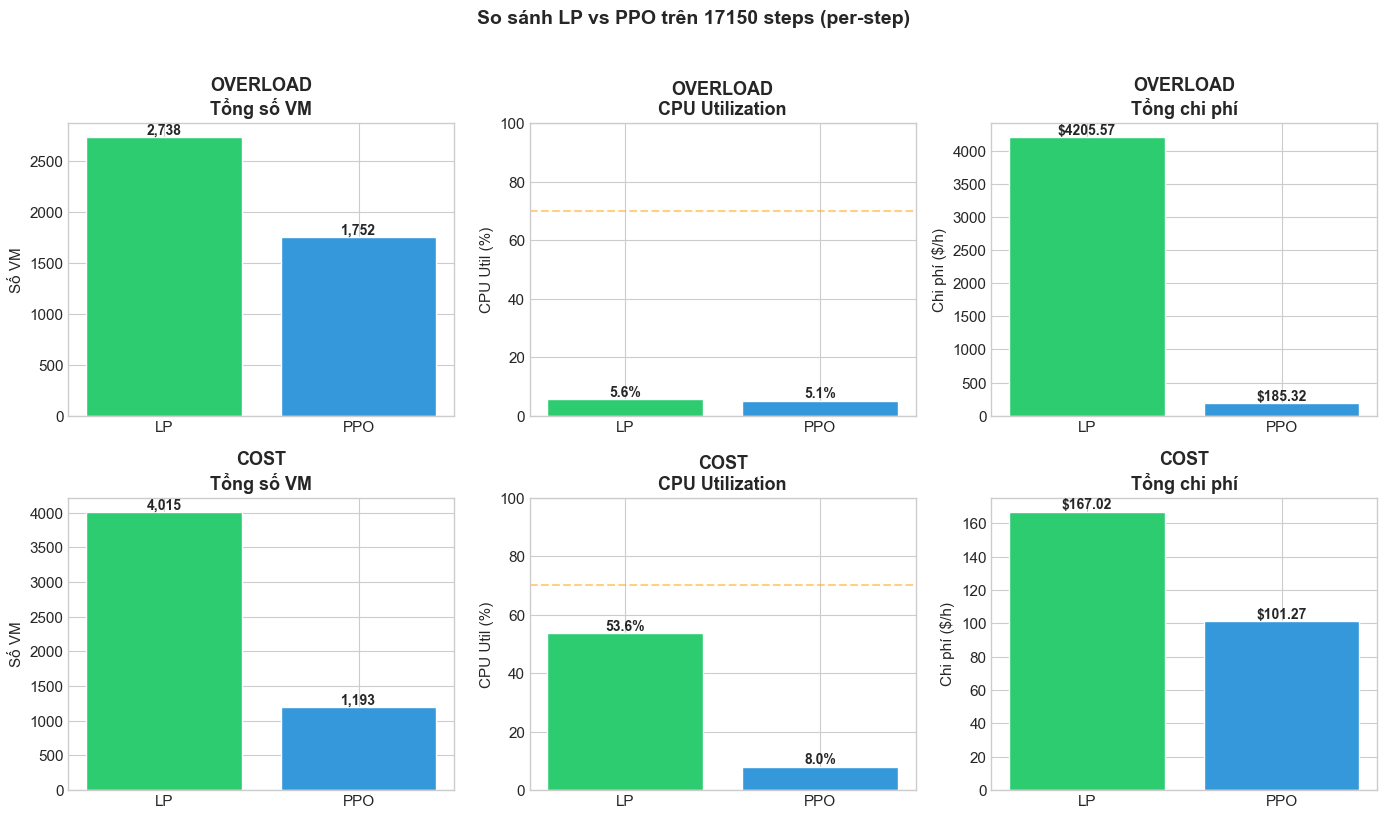

✓ Chart saved to forecast_result\lp_vs_ppo_by_scenario.png


In [46]:
def plot_scenario(metrics_list, scenario_name, ax_row):
    """Plot 3 criteria for a scenario"""
    if len(metrics_list) < 2:
        return
    
    df = pd.DataFrame(metrics_list).set_index('Method')
    methods = df.index.tolist()
    colors = [COLORS.get(m, '#999999') for m in methods]
    
    # 1. Total VMs
    ax = ax_row[0]
    vals = df['Total VMs'].values
    bars = ax.bar(methods, vals, color=colors, edgecolor='white')
    ax.set_title(f'{scenario_name}\nTổng số VM', fontweight='bold')
    ax.set_ylabel('Số VM')
    for bar, val in zip(bars, vals):
        ax.annotate(f'{val:,}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 2. CPU Utilization
    ax = ax_row[1]
    vals = df['CPU Util %'].values
    bars = ax.bar(methods, vals, color=colors, edgecolor='white')
    ax.set_title(f'{scenario_name}\nCPU Utilization', fontweight='bold')
    ax.set_ylabel('CPU Util (%)')
    ax.set_ylim(0, 100)
    ax.axhline(y=70, color='orange', linestyle='--', alpha=0.5)
    for bar, val in zip(bars, vals):
        ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 3. Total Cost
    ax = ax_row[2]
    vals = df['Total Cost ($/h)'].values
    bars = ax.bar(methods, vals, color=colors, edgecolor='white')
    ax.set_title(f'{scenario_name}\nTổng chi phí', fontweight='bold')
    ax.set_ylabel('Chi phí ($/h)')
    for bar, val in zip(bars, vals):
        ax.annotate(f'${val:.2f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

# Tạo figure 2 hàng (Overload, Cost) x 3 cột (VM, Util, Cost)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle(f'So sánh LP vs PPO trên {n_steps} steps (per-step)', 
             fontsize=14, fontweight='bold', y=1.02)

# Row 1: OVERLOAD scenario
plot_scenario(metrics_overload, 'OVERLOAD', axes[0])

# Row 2: COST scenario  
plot_scenario(metrics_cost, 'COST', axes[1])

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'lp_vs_ppo_by_scenario.png', dpi=150, 
            bbox_inches='tight', facecolor='white')
plt.show()
print(f'✓ Chart saved to {RESULTS_DIR / "lp_vs_ppo_by_scenario.png"}')


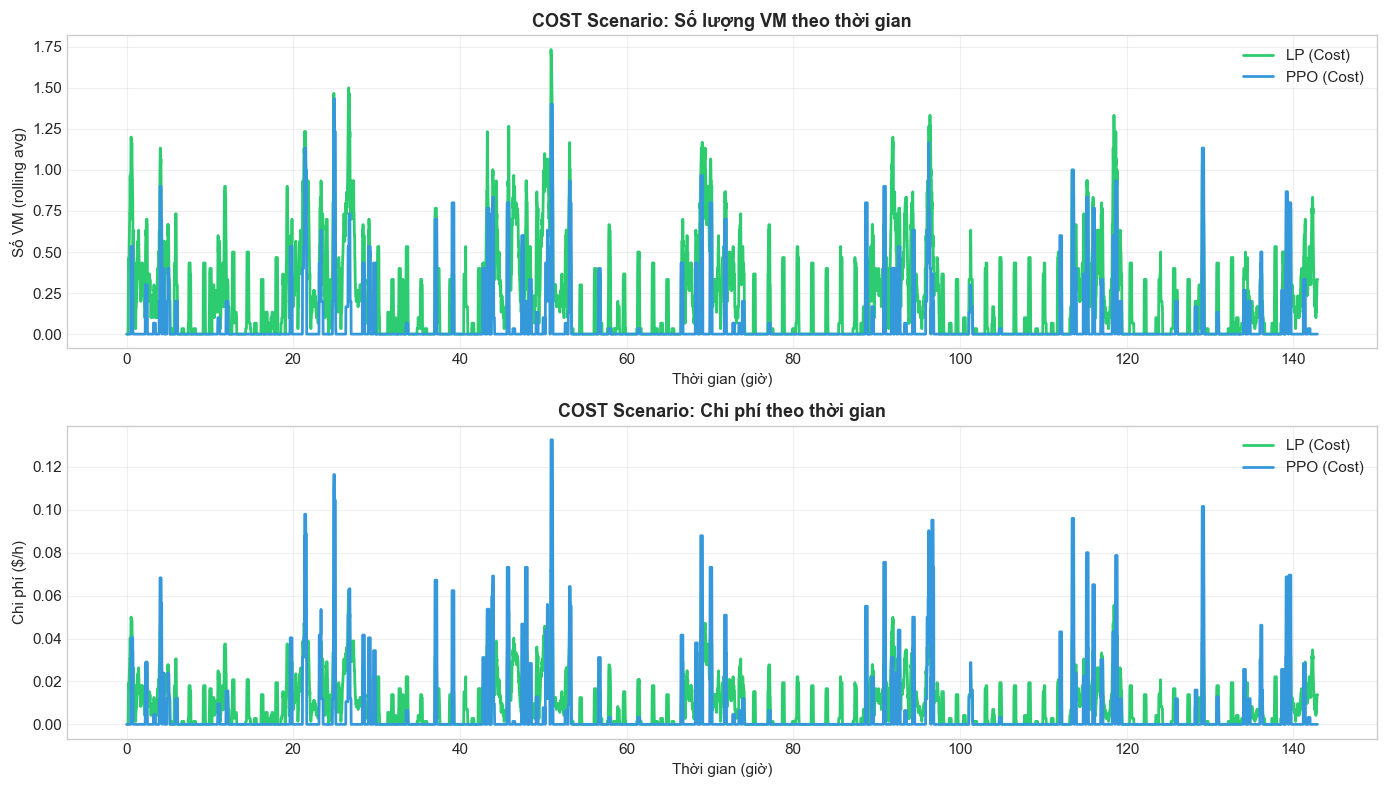

✓ Time series chart saved


In [47]:
# Time series: VM count theo thời gian (Scenario: COST)
if lp_cost_df is not None:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    window = 30  # Rolling window

    x_hours = np.arange(n_steps) * 30 / 3600

    # Plot 1: VM Count
    ax1 = axes[0]
    ax1.plot(x_hours, lp_cost_df['vm_count'].rolling(window, min_periods=1).mean(), 
             label='LP (Cost)', color=COLORS['LP'], linewidth=2)
    ax1.plot(x_hours, ppo_cost_df['vm_count'].rolling(window, min_periods=1).mean(), 
             label='PPO (Cost)', color=COLORS['PPO'], linewidth=2)
    ax1.set_xlabel('Thời gian (giờ)')
    ax1.set_ylabel('Số VM (rolling avg)')
    ax1.set_title('COST Scenario: Số lượng VM theo thời gian', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Cost
    ax2 = axes[1]
    ax2.plot(x_hours, lp_cost_df['vm_cost_per_hour'].rolling(window, min_periods=1).mean(), 
             label='LP (Cost)', color=COLORS['LP'], linewidth=2)
    ax2.plot(x_hours, ppo_cost_df['vm_cost_per_hour'].rolling(window, min_periods=1).mean(), 
             label='PPO (Cost)', color=COLORS['PPO'], linewidth=2)
    ax2.set_xlabel('Thời gian (giờ)')
    ax2.set_ylabel('Chi phí ($/h)')
    ax2.set_title('COST Scenario: Chi phí theo thời gian', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'lp_vs_ppo_timeseries_cost.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print('✓ Time series chart saved')


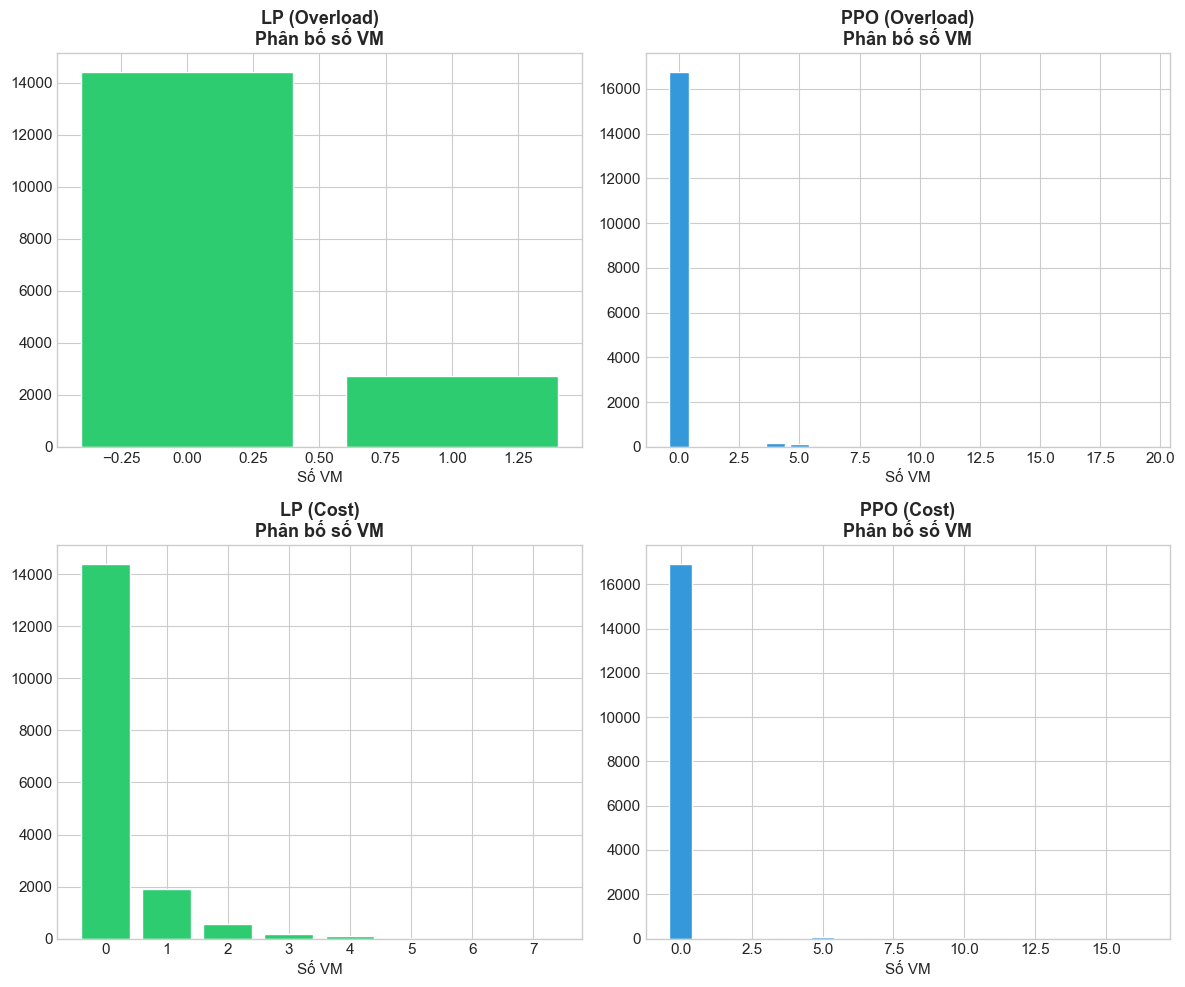

✓ VM distribution chart saved


In [48]:
# Distribution của số VM theo Scenario
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# OVERLOAD scenario
if lp_overload_df is not None:
    vm_counts = lp_overload_df['vm_count'].value_counts().sort_index()
    axes[0, 0].bar(vm_counts.index, vm_counts.values, color=COLORS['LP'], edgecolor='white')
    axes[0, 0].set_title('LP (Overload)\nPhân bố số VM', fontweight='bold')
    axes[0, 0].set_xlabel('Số VM')

vm_counts = ppo_overload_df['vm_count'].value_counts().sort_index()
axes[0, 1].bar(vm_counts.index, vm_counts.values, color=COLORS['PPO'], edgecolor='white')
axes[0, 1].set_title('PPO (Overload)\nPhân bố số VM', fontweight='bold')
axes[0, 1].set_xlabel('Số VM')

# COST scenario
if lp_cost_df is not None:
    vm_counts = lp_cost_df['vm_count'].value_counts().sort_index()
    axes[1, 0].bar(vm_counts.index, vm_counts.values, color=COLORS['LP'], edgecolor='white')
    axes[1, 0].set_title('LP (Cost)\nPhân bố số VM', fontweight='bold')
    axes[1, 0].set_xlabel('Số VM')

vm_counts = ppo_cost_df['vm_count'].value_counts().sort_index()
axes[1, 1].bar(vm_counts.index, vm_counts.values, color=COLORS['PPO'], edgecolor='white')
axes[1, 1].set_title('PPO (Cost)\nPhân bố số VM', fontweight='bold')
axes[1, 1].set_xlabel('Số VM')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'lp_vs_ppo_vm_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ VM distribution chart saved')


## 5. Phân tích Chi tiết


In [49]:
# Phân tích chi tiết theo SCENARIO
def analyze_scenario(metrics_list, scenario_name):
    """Phân tích và so sánh LP vs PPO cho một scenario"""
    if len(metrics_list) < 2:
        print(f"⚠️ Thiếu dữ liệu cho scenario {scenario_name}")
        return None
    
    lp_m = metrics_list[0]  # LP
    ppo_m = metrics_list[1]  # PPO
    
    print(f"\n{'='*60}")
    print(f"    SCENARIO: {scenario_name}")
    print(f"{'='*60}")
    
    # VM comparison
    print("\n📊 Tổng số VM:")
    print(f"   LP:  {lp_m['Total VMs']:>6} VMs (avg {lp_m['Avg VMs/Step']:.2f}/step)")
    print(f"   PPO: {ppo_m['Total VMs']:>6} VMs (avg {ppo_m['Avg VMs/Step']:.2f}/step)")
    if lp_m['Total VMs'] > 0:
        diff = (ppo_m['Total VMs'] - lp_m['Total VMs']) / lp_m['Total VMs'] * 100
        print(f"   → PPO {'nhiều hơn' if diff > 0 else 'ít hơn'} LP: {abs(diff):.1f}%")
    
    # Utilization
    print("\n📊 CPU Utilization (khi có VM):")
    print(f"   LP:  {lp_m['CPU Util %']:>6.1f}%")
    print(f"   PPO: {ppo_m['CPU Util %']:>6.1f}%")
    
    # Cost
    print("\n📊 Chi phí vận hành:")
    print(f"   LP:  ${lp_m['Total Cost ($/h)']:>8.4f}")
    print(f"   PPO: ${ppo_m['Total Cost ($/h)']:>8.4f}")
    if lp_m['Total Cost ($/h)'] > 0:
        diff = (ppo_m['Total Cost ($/h)'] - lp_m['Total Cost ($/h)']) / lp_m['Total Cost ($/h)'] * 100
        print(f"   → PPO {'đắt hơn' if diff > 0 else 'rẻ hơn'} LP: {abs(diff):.1f}%")
    
    # SLA
    print("\n📊 Vi phạm SLA:")
    print(f"   LP:  {lp_m['SLA Violations']:>4} ({lp_m['SLA Violations']/lp_m['Steps']*100:.2f}%)")
    print(f"   PPO: {ppo_m['SLA Violations']:>4} ({ppo_m['SLA Violations']/ppo_m['Steps']*100:.2f}%)")
    
    # Winner for each criterion
    return {
        'scenario': scenario_name,
        'vm': 'LP' if lp_m['Total VMs'] <= ppo_m['Total VMs'] else 'PPO',
        'util': 'LP' if lp_m['CPU Util %'] >= ppo_m['CPU Util %'] else 'PPO',
        'cost': 'LP' if lp_m['Total Cost ($/h)'] <= ppo_m['Total Cost ($/h)'] else 'PPO',
        'sla': 'LP' if lp_m['SLA Violations'] <= ppo_m['SLA Violations'] else 'PPO',
    }

print("="*70)
print("           PHÂN TÍCH CHI TIẾT LP vs PPO (PER-STEP)")
print("="*70)

results_overload = analyze_scenario(metrics_overload, 'OVERLOAD') if len(metrics_overload) >= 2 else None
results_cost = analyze_scenario(metrics_cost, 'COST') if len(metrics_cost) >= 2 else None


           PHÂN TÍCH CHI TIẾT LP vs PPO (PER-STEP)

    SCENARIO: OVERLOAD

📊 Tổng số VM:
   LP:    2738 VMs (avg 0.16/step)
   PPO:   1752 VMs (avg 0.10/step)
   → PPO ít hơn LP: 36.0%

📊 CPU Utilization (khi có VM):
   LP:     5.6%
   PPO:    5.1%

📊 Chi phí vận hành:
   LP:  $4205.5680
   PPO: $185.3248
   → PPO rẻ hơn LP: 95.6%

📊 Vi phạm SLA:
   LP:     0 (0.00%)
   PPO:    5 (0.03%)

    SCENARIO: COST

📊 Tổng số VM:
   LP:    4015 VMs (avg 0.23/step)
   PPO:   1193 VMs (avg 0.07/step)
   → PPO ít hơn LP: 70.3%

📊 CPU Utilization (khi có VM):
   LP:    53.6%
   PPO:    8.0%

📊 Chi phí vận hành:
   LP:  $167.0240
   PPO: $101.2704
   → PPO rẻ hơn LP: 39.4%

📊 Vi phạm SLA:
   LP:     0 (0.00%)
   PPO:  174 (1.01%)


In [50]:
# Tổng kết winner
print("\n" + "="*70)
print("                         TỔNG KẾT WINNER")
print("="*70)
print(f"\n{'Tiêu chí':<25} {'OVERLOAD':>15} {'COST':>15}")
print("-"*55)
if results_overload and results_cost:
    print(f"{'Ít VM hơn':<25} {results_overload['vm']:>15} {results_cost['vm']:>15}")
    print(f"{'Hiệu quả hơn (CPU)':<25} {results_overload['util']:>15} {results_cost['util']:>15}")
    print(f"{'Chi phí thấp hơn':<25} {results_overload['cost']:>15} {results_cost['cost']:>15}")
    print(f"{'SLA tốt hơn':<25} {results_overload['sla']:>15} {results_cost['sla']:>15}")



                         TỔNG KẾT WINNER

Tiêu chí                         OVERLOAD            COST
-------------------------------------------------------
Ít VM hơn                             PPO             PPO
Hiệu quả hơn (CPU)                     LP              LP
Chi phí thấp hơn                      PPO             PPO
SLA tốt hơn                            LP              LP


In [51]:
# Nhận xét
print("\n" + "-"*70)
print("NHẬN XÉT:")
print("-"*70)
print("""
• LP (Linear Programming):
  - Giải tối ưu chính xác tại mỗi thời điểm
  - Reactive: chỉ dùng thông tin hiện tại
  - Hai kịch bản: Overload (capacity-first) và Cost (cost-first)

• PPO (Proximal Policy Optimization):
  - Học từ dữ liệu, có thể học pattern
  - Hai kịch bản với reward weights khác nhau
  - Post-processing: Host-only khi không có overflow
""")



----------------------------------------------------------------------
NHẬN XÉT:
----------------------------------------------------------------------

• LP (Linear Programming):
  - Giải tối ưu chính xác tại mỗi thời điểm
  - Reactive: chỉ dùng thông tin hiện tại
  - Hai kịch bản: Overload (capacity-first) và Cost (cost-first)

• PPO (Proximal Policy Optimization):
  - Học từ dữ liệu, có thể học pattern
  - Hai kịch bản với reward weights khác nhau
  - Post-processing: Host-only khi không có overflow



In [52]:
# Summary table with all 4 methods
print("\n" + "="*70)
print("           BẢNG TỔNG HỢP TẤT CẢ PHƯƠNG PHÁP")
print("="*70)

all_methods = []
if len(metrics_overload) >= 2:
    all_methods.append({**metrics_overload[0], 'Method': 'LP (Overload)'})
    all_methods.append({**metrics_overload[1], 'Method': 'PPO (Overload)'})
if len(metrics_cost) >= 2:
    all_methods.append({**metrics_cost[0], 'Method': 'LP (Cost)'})
    all_methods.append({**metrics_cost[1], 'Method': 'PPO (Cost)'})

if all_methods:
    summary_df = pd.DataFrame(all_methods).set_index('Method')
    display(summary_df[['Total VMs', 'CPU Util %', 'Total Cost ($/h)', 'SLA Violations']])



           BẢNG TỔNG HỢP TẤT CẢ PHƯƠNG PHÁP


,Total VMs,CPU Util %,Total Cost ($/h),SLA Violations
Method,,,,
LP (Overload),2738,5.60,4205.5680,0
PPO (Overload),1752,5.10,185.3248,5
LP (Cost),4015,53.62,167.0240,0
PPO (Cost),1193,8.02,101.2704,174


## 6. Kết luận & Nhận xét


In [53]:
# Kết luận cuối cùng
print('='*70)
print('                         KẾT LUẬN')
print('='*70)

if all_methods:
    # Xác định tốt nhất overall
    best_vm = min(all_methods, key=lambda x: x['Total VMs'])
    best_util = max(all_methods, key=lambda x: x['CPU Util %'])
    best_cost = min(all_methods, key=lambda x: x['Total Cost ($/h)'])
    best_sla = min(all_methods, key=lambda x: x['SLA Violations'])
    
    print(f"\n🏆 Ít VM nhất (overall):          {best_vm['Method']}")
    print(f"🏆 CPU hiệu quả nhất (overall):   {best_util['Method']}")
    print(f"🏆 Chi phí thấp nhất (overall):   {best_cost['Method']}")
    print(f"🏆 SLA tốt nhất (overall):        {best_sla['Method']}")


                         KẾT LUẬN

🏆 Ít VM nhất (overall):          PPO (Cost)
🏆 CPU hiệu quả nhất (overall):   LP (Cost)
🏆 Chi phí thấp nhất (overall):   PPO (Cost)
🏆 SLA tốt nhất (overall):        LP (Overload)


In [54]:
# Lưu kết quả so sánh theo scenario
comparison_result = {
    'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'comparison_type': 'per-step by scenario',
    'n_steps': n_steps,
    'scenarios': {
        'overload': {
            'LP': metrics_overload[0] if len(metrics_overload) > 0 else None,
            'PPO': metrics_overload[1] if len(metrics_overload) > 1 else None,
            'winner': results_overload if results_overload else None,
        },
        'cost': {
            'LP': metrics_cost[0] if len(metrics_cost) > 0 else None,
            'PPO': metrics_cost[1] if len(metrics_cost) > 1 else None,
            'winner': results_cost if results_cost else None,
        },
    },
    'overall_best': {
        'vm_count': best_vm['Method'] if all_methods else None,
        'utilization': best_util['Method'] if all_methods else None,
        'cost': best_cost['Method'] if all_methods else None,
        'sla': best_sla['Method'] if all_methods else None,
    }
}

with open(RESULTS_DIR / 'lp_vs_ppo_comparison_by_scenario.json', 'w') as f:
    json.dump(comparison_result, f, indent=2)

print(f'\n✓ Comparison results saved to {RESULTS_DIR / "lp_vs_ppo_comparison_by_scenario.json"}')
print(f'✓ Charts saved to {RESULTS_DIR}/')



✓ Comparison results saved to forecast_result\lp_vs_ppo_comparison_by_scenario.json
✓ Charts saved to forecast_result/
